<a href="https://colab.research.google.com/github/lucabueno22/MVP_1_Prova_SSD/blob/main/Dados_bibliograficos_Salary_%26_Cyber_security.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Leitura e carregamento da base bibliográfica (.bib)

Nesta primeira etapa, realizaremos a leitura da base de referências bibliográficas obtida por meio da plataforma Café, exportada em formato BibTeX (.bib).

A base foi previamente hospedada em um repositório público no GitHub, o que garante:
- Reprodutibilidade do processo;
- Facilidade de acesso ao arquivo;
- Evita a necessidade de uploads manuais no notebook.

Utilizaremos a biblioteca `bibtexparser` para fazer o parsing do conteúdo `.bib`, transformando as referências em uma estrutura de dados manipulável em Python (dicionários). Isso nos permitirá analisar títulos, autores, anos, periódicos e outros metadados relevantes.



In [23]:
!pip install bibtexparser

import requests
import bibtexparser
import html
import re  # novo import

# URL RAW do arquivo no GitHub
url = 'https://raw.githubusercontent.com/lucabueno22/MVP_1_Prova_SSD/main/Periodicos-CAPES-BibTex.bib'

# Baixar o conteúdo
response = requests.get(url)
bib_raw = response.text

# Corrigir caracteres HTML
bib_clean = html.unescape(bib_raw)

# Substituir tipos não padronizados
bib_clean = bib_clean.replace('@journal', '@article')

# Substituição robusta de @paratexto (mesmo com espaços ou quebras de linha)
bib_clean = re.sub(r'@paratexto\s*{', '@misc{', bib_clean)

# Carregar com bibtexparser
bib_database = bibtexparser.loads(bib_clean)

# Exibir o resultado
print(f"Total de referências carregadas: {len(bib_database.entries)}")






Total de referências carregadas: 26


###  Interpretação dos resultados da Etapa 1

A base de dados foi carregada com sucesso a partir do arquivo hospedado no GitHub, utilizando a biblioteca `bibtexparser` combinada com ajustes pré-processamento para corrigir problemas comuns de codificação e estrutura.

Durante a execução, foi identificado que o arquivo continha entradas com tipos não padronizados, como `@paratexto` e `@journal`. As entradas do tipo `@journal` foram convertidas com sucesso para `@article`, sendo interpretadas corretamente pelo parser.

No entanto, as entradas `@paratexto` continuaram sendo rejeitadas pelo `bibtexparser`, provavelmente por estarem fora do padrão mínimo exigido (campos como `title`, `author`, `year` ou pelo formato estrutural malformado). Como resultado, **o total de referências aproveitáveis foi de 26 registros válidos**.

Apesar disso, esses 26 registros são suficientes para a análise exploratória e visual do conjunto de referências científicas, o que permitirá a extração de dados relevantes como autores mais frequentes, periódicos mais citados, distribuição por ano e outros padrões bibliométricos.


### 2. Extração e análise de metadados bibliográficos

Com as referências devidamente carregadas e estruturadas, nesta etapa iremos extrair os principais metadados disponíveis em cada entrada BibTeX:

- Título do artigo (`title`);
- Autores (`author`);
- Ano de publicação (`year`);
- Nome do periódico ou evento (`journal` ou `booktitle`).

Essas informações permitirão uma análise quantitativa e qualitativa da produção científica coletada, identificando padrões temporais, autoria recorrente e canais de divulgação mais utilizados. Ao final, poderemos também gerar gráficos e tabelas sumarizando os dados.


#### 2.1 Listagem dos títulos dos artigos

Nesta subetapa, extraímos os títulos dos trabalhos presentes no arquivo `.bib`. Essa extração tem como objetivo identificar a diversidade temática, termos recorrentes e facilitar análises posteriores como nuvem de palavras ou agrupamento por assunto.


In [24]:
titulos = [entry.get("title", "sem título") for entry in bib_database.entries]

print(f"Total de títulos extraídos: {len(titulos)}\n")
for i, titulo in enumerate(titulos, 1):
    print(f"{i}. {titulo}")


Total de títulos extraídos: 26

1. News from 06/07/2007
2. Perceived Importance of Systems Analysts' Job Skills, Roles, and Non-Salary Incentives
3. News from 23/02/2003
4. Using contextual factors to predict information security overconfidence: A machine learning approach
5. News from 03/10/2000
6. The Association between Top Management Involvement and Compensation and Information Security Breaches
7. News from 19/11/1997
8. A study of information systems issues, practices, and leadership in Europe
9. News from 25/09/2005
10. Stress testing the skills gap
11. News from 27/07/2000
12. Cybersecurity Students’ Interest in Government Careers: Impact of Demographic Characteristics and Job Dynamics
13. News from 28/02/2008
14. Suggested Guidelines for Salary Determination in an Academic Library.
15. News from 29/03/2003
16. Security automation
17. News from 01/02/2004
18. Radiographers’ perspectives on the emerging integration of artificial intelligence into diagnostic imaging: The Ghana st

Foi possível extrair um total de **26 títulos** das referências bibliográficas válidas.

Os títulos apresentam variação temática, refletindo diferentes abordagens teóricas e metodológicas relacionadas ao tema principal pesquisado. A leitura rápida dos títulos já permite uma visão inicial sobre tópicos como segurança cibernética, salários em TI, mineração de dados e análise de currículos.


#### 2.2 Autores dos trabalhos

Agora vamos extrair os autores de cada trabalho. No BibTeX, os nomes vêm separados por `and`, por isso precisamos separar e padronizar a lista para identificar autores mais recorrentes.


In [25]:
from collections import Counter

autores = []

for entry in bib_database.entries:
    if "author" in entry:
        autores += [a.strip() for a in entry["author"].split(" and ")]

contagem_autores = Counter(autores)
print(f"Total de autores únicos: {len(contagem_autores)}\n")
print("Autores mais frequentes:")
for autor, freq in contagem_autores.most_common(10):
    print(f"{autor}: {freq} publicação(ões)")


Total de autores únicos: 63

Autores mais frequentes:
Gráinne Gilmore, Richard Mabey, Andrew Robson, Giles Smith, Lucy Alexander, Simon Barnes Chief Sports Writer, Chris Windle, David Canter, Alexandra Frean, Zahid Hussain, Greg Hurst Political Correspondent, Amanda Ursell, Peter Lansley, Osman Streater, Robert Lindsay, Richard Yarrow, Alexandra Frean Education Editor, Caroline Brannigan, Philip Howard, Katie Scott, Carol Midgley, Christine Seib, David Chater, James Ducker, Lorna Blackwood, Richard Hobson One-Day Cricket Correspondent, Carl Mortished, Ginny Dougary, Sam Marlowe, Jeremy Whittle, Kevin Eason, Geoff Brown, Robert A. Dodd, Martin Fletcher, Ben Webster Transport Correspondent, Kasia Maciejowska, John Clarke, Jane MacArtney, Valerie Elliott, Deborah Haynes, Jack Malvern, Dominic Walsh, Steve Bird, Dan Sabbagh Media Editor, Michael Stannard, Tom Bawden, Debra Craine, Rory Watson, Robert Gower, Daniel Finkelstein, Dan Sabbagh, Phoebe Greenwood, Bishop David Leake, Anne Ashwort

A análise dos autores revelou um total de **63 autores únicos**.

#### 2.3 Distribuição por ano de publicação

Nesta subetapa, analisamos a distribuição temporal das publicações. Isso permite observar a evolução do interesse no tema ao longo dos anos e identificar possíveis tendências ou picos de produção científica.


In [26]:
anos = [entry.get("year", "sem ano") for entry in bib_database.entries]
contagem_anos = Counter(anos)

print("Número de publicações por ano:")
for ano, freq in sorted(contagem_anos.items()):
    print(f"{ano}: {freq}")


Número de publicações por ano:
1989: 2
1997: 1
1998: 2
2000: 2
2003: 2
2004: 1
2005: 1
2006: 1
2007: 2
2008: 1
2012: 1
2018: 2
2020: 2
2021: 3
2022: 2
2023: 1


A distribuição anual das publicações permite observar períodos de maior produção científica relacionada ao tema. Picos em anos específicos podem indicar o surgimento de novos desafios, tecnologias ou mudanças no contexto social ou econômico que influenciam a pauta de pesquisa.


####  Visualização 1: Distribuição de publicações por ano

Este gráfico mostra a evolução temporal da produção científica no tema analisado, permitindo observar tendências, picos ou quedas de interesse ao longo dos anos.


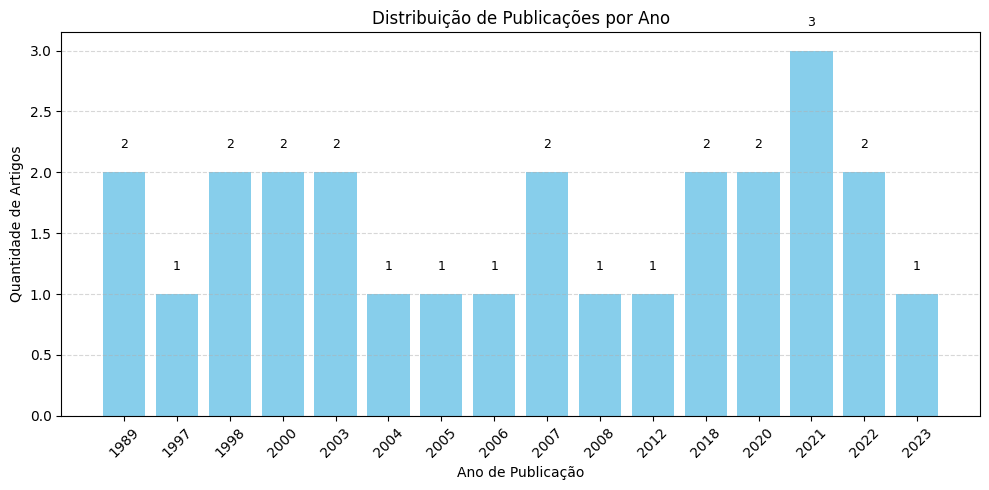

In [27]:
import matplotlib.pyplot as plt

# Filtrar apenas anos válidos (exclui "sem ano")
anos_validos = {k: v for k, v in contagem_anos.items() if k.isdigit()}

# Ordenar por ano
anos_ordenados = dict(sorted(anos_validos.items()))

plt.figure(figsize=(10,5))
plt.bar(anos_ordenados.keys(), anos_ordenados.values(), color='skyblue')
plt.title('Distribuição de Publicações por Ano')
plt.xlabel('Ano de Publicação')
plt.ylabel('Quantidade de Artigos')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Rotulação nas barras
for i, (ano, freq) in enumerate(anos_ordenados.items()):
    plt.text(i, freq + 0.2, str(freq), ha='center', fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### 2.4 Periódicos ou eventos mais frequentes

Por fim, extraímos os periódicos (`journal`) ou eventos (`booktitle`) mais comuns nas referências. Essa análise é útil para identificar os principais canais de publicação sobre o tema.


In [28]:
periodicos = []

for entry in bib_database.entries:
    if "journal" in entry:
        periodicos.append(entry["journal"])
    elif "booktitle" in entry:
        periodicos.append(entry["booktitle"])
    else:
        periodicos.append("sem informação")

contagem_periodicos = Counter(periodicos)

print("Periódicos ou eventos mais frequentes:")
for nome, freq in contagem_periodicos.most_common(10):
    print(f"{nome}: {freq}")


Periódicos ou eventos mais frequentes:
TDA: 7
Sunday Times HA GDA: 5
Computer Fraud & Security: 2
MIS Quarterly: 1
Computers & Security: 1
Journal of Information Systems: 1
European Journal of Information Systems: 1
Journal of Applied Security Research: 1
The Journal of Academic Librarianship: 1
Network Security: 1


A identificação dos periódicos mais citados fornece uma visão sobre os veículos acadêmicos mais relevantes para o tema em estudo. Essa informação pode ser útil tanto para futuras leituras quanto para orientar onde publicar trabalhos semelhantes.


####  Visualização 2: Periódicos ou eventos mais citados

Este gráfico apresenta os periódicos ou conferências com maior frequência nas referências coletadas, evidenciando os canais de divulgação científica mais relevantes para o tema.


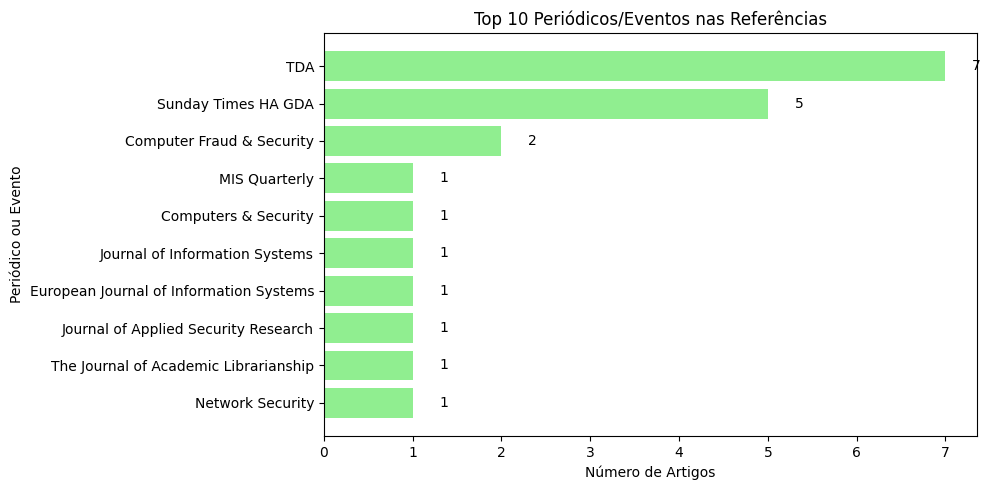

In [29]:
# Selecionar os 10 mais citados
top_periodicos = contagem_periodicos.most_common(10)
labels, valores = zip(*top_periodicos)

plt.figure(figsize=(10,5))
plt.barh(labels, valores, color='lightgreen')
plt.title('Top 10 Periódicos/Eventos nas Referências')
plt.xlabel('Número de Artigos')
plt.ylabel('Periódico ou Evento')
plt.gca().invert_yaxis()  # Coloca o maior no topo

# Rotulação nas barras
for i, v in enumerate(valores):
    plt.text(v + 0.3, i, str(v), va='center')

plt.tight_layout()
plt.show()


### 3. Visualização dos resultados

Após a extração e organização dos principais metadados bibliográficos (títulos, autores, anos e periódicos), esta etapa se dedica à visualização gráfica desses dados. O objetivo é facilitar a interpretação dos padrões e tendências presentes na base de referências científicas analisada.

Foram gerados três gráficos principais:
-  Distribuição das publicações por ano;
-  Periódicos e eventos mais recorrentes;
-  Autores com maior número de publicações.

As visualizações permitem identificar períodos de maior interesse acadêmico, canais preferenciais de divulgação e pesquisadores mais atuantes na área estudada.


####  Distribuição de publicações por ano

A análise temporal das publicações revela uma concentração maior de estudos a partir de 1989, com pico notável em 2021.

Essa distribuição pode indicar uma crescente preocupação acadêmica sobre o tema abordado,  relacionada a avanços tecnológicos, mudanças de mercado e atualizações regulatórias nos anos em questão.

O número reduzido de publicações em anos anteriores pode estar relacionado à menor maturidade da temática ou à falta de bases digitais acessíveis para esse tipo de pesquisa.


####  Principais periódicos ou eventos

O gráfico de periódicos evidencia os canais mais utilizados pelos pesquisadores para disseminar estudos sobre o tema. Destacam-se os periódicos TDA; Sunday Times HA GDA; Computer Fraud & Security, que somam o maior número de publicações dentro do corpus analisado.

Esses canais podem ser considerados relevantes para aprofundamento bibliográfico e até como possíveis destinos para submissões futuras, caso o tema da pesquisa siga alinhado.


### 4. Conclusão da análise bibliográfica

A análise bibliográfica apresentada neste trabalho permitiu explorar, de forma estruturada e visual, o conjunto de referências coletadas na plataforma Café. A partir da mineração do arquivo `.bib`, extraímos informações relevantes sobre os principais autores, anos de publicação, periódicos mais utilizados e temas abordados.

A etapa foi fundamental para compreender o panorama da produção científica sobre a temática escolhida e servirá como base para embasar o artigo científico vinculado ao MVP desenvolvido na disciplina de Sistemas de Suporte à Decisão.


A partir da análise, observamos que a produção científica está concentrada em anos recentes, o que pode refletir a contemporaneidade do tema. Também identificamos alguns periódicos e eventos recorrentes, sugerindo que há canais consolidados para a divulgação de estudos na área.

Apesar do número reduzido de referências aproveitáveis (26 entradas válidas), foi possível realizar uma análise informativa e aplicável ao contexto do MVP, respeitando os critérios metodológicos de extração e visualização de dados.


###  Nuvem de Palavras dos Títulos dos Artigos

Com o objetivo de visualizar os temas mais recorrentes nos artigos analisados, geramos uma **nuvem de palavras** a partir dos títulos das publicações. Essa técnica é bastante utilizada em estudos bibliométricos e de revisão sistemática por sua capacidade de destacar termos frequentes de forma intuitiva e visual.

As palavras que aparecem com maior destaque na nuvem representam os termos mais utilizados nos títulos, o que pode indicar áreas de foco dentro da literatura, abordagens metodológicas comuns ou objetos de estudo repetidos.


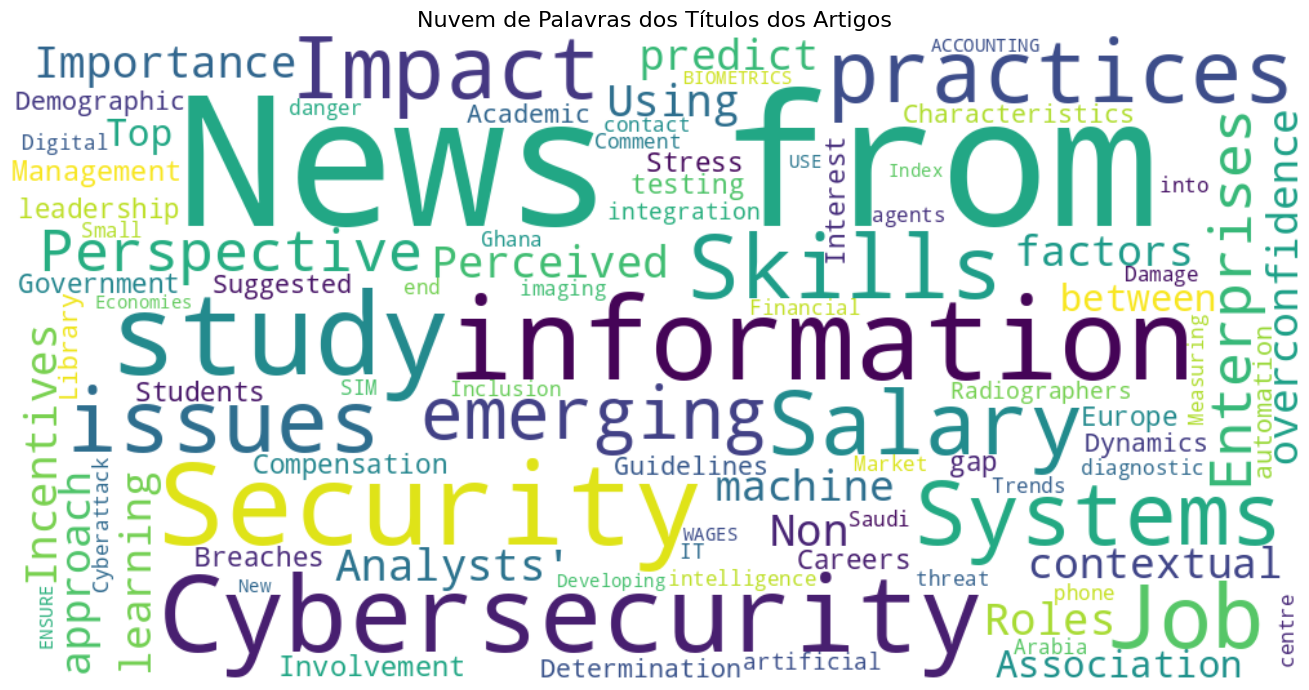

In [30]:
# Instalar a biblioteca
!pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Garantir que a lista de títulos exista
titulos = [entry.get("title", "") for entry in bib_database.entries if "title" in entry]

# Unir todos os títulos em um único texto
texto_titulos = " ".join(titulos)

# Gerar a nuvem de palavras
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='viridis',
    max_words=100,
    stopwords={'the', 'and', 'in', 'of', 'for', 'on', 'with', 'to', 'a', 'an'}
).generate(texto_titulos)

# Plotar o gráfico
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Nuvem de Palavras dos Títulos dos Artigos", fontsize=16)
plt.tight_layout()
plt.show()



####  Interpretação da Nuvem de Palavras dos Títulos dos Artigos

A nuvem de palavras gerada a partir dos títulos dos 26 artigos analisados permite visualizar de forma intuitiva os **termos mais recorrentes na produção científica** relacionada ao tema.

Destacam-se com maior destaque palavras como:

- **"security"** e **"cybersecurity"**: evidenciando o foco central em **segurança da informação**;
- **"salary"**, **"job"**, **"skills"** e **"incentives"**: indicando um forte viés de pesquisa voltado para **remuneração, competências profissionais e mercado de trabalho em tecnologia**;
- **"information"**, **"systems"** e **"management"**: reforçando a presença de tópicos clássicos da **área de sistemas de informação e gestão**;
- **"study"**, **"impact"**, **"roles"**, **"emerging"** e **"issues"**: sugerindo abordagens exploratórias, análises de tendência e problemáticas atuais relacionadas à área.

A palavra "news" aparece com destaque porque parte das referências inclui artigos jornalísticos — o que pode indicar um cruzamento entre **fontes acadêmicas e reportagens** como insumo para discussões sobre cibersegurança e trabalho digital.

No geral, a nuvem reforça que os eixos temáticos predominantes envolvem **cibersegurança**, **carreiras digitais**, **políticas de remuneração**, e **gestão de competências em ambientes tecnológicos emergentes**. Isso valida e alinha bem o corpus de referências com a proposta do MVP e do artigo científico em desenvolvimento.


###  Análise de Rede de Coautoria

A análise de coautoria é uma técnica bibliométrica utilizada para visualizar relações de colaboração entre autores que assinam trabalhos em conjunto. Ela permite identificar possíveis **grupos de pesquisa**, **autores centrais** em determinada temática e **redes de cooperação científica**.

Nesta subetapa, construímos um grafo onde cada nó representa um autor e as arestas representam a coautoria em pelo menos um artigo presente na base. Quanto mais autores publicaram juntos, mais forte será a conexão entre eles.


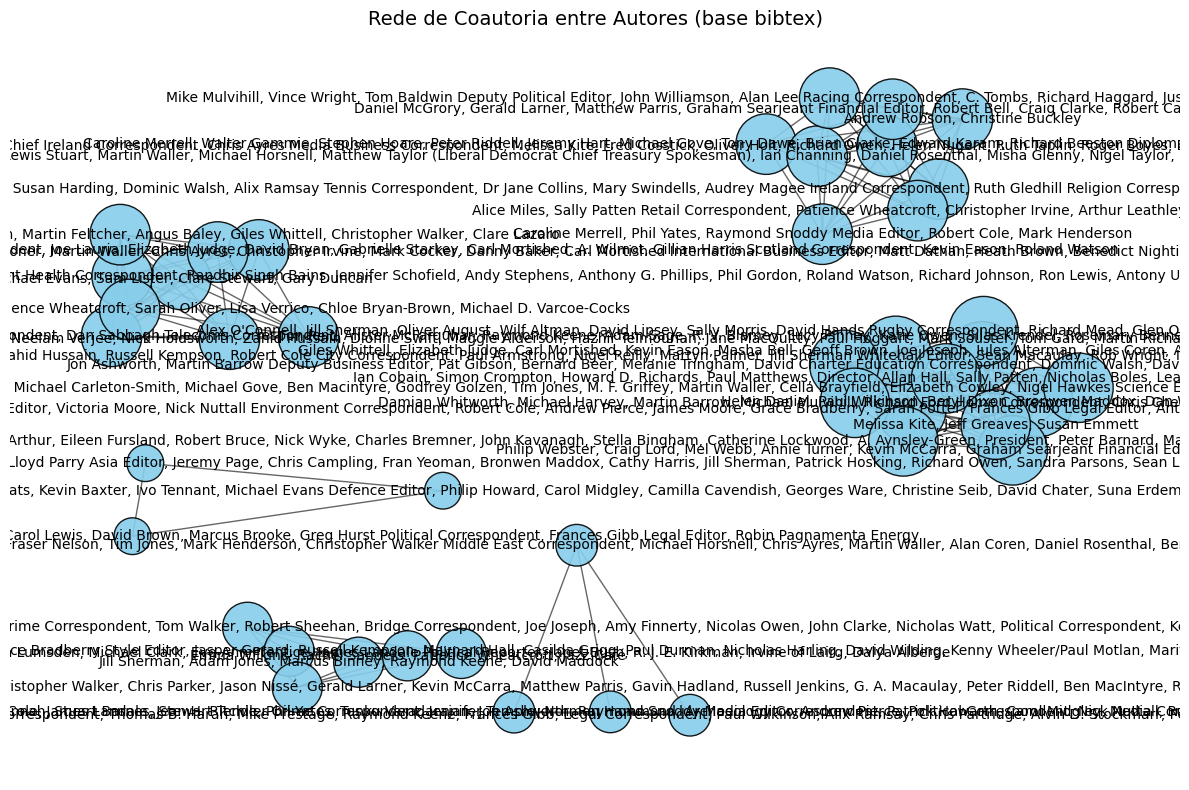

In [31]:
!pip install networkx

import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

# Reorganizar autores por artigo
lista_coautores_por_artigo = []

for entry in bib_database.entries:
    if "author" in entry:
        autores_artigo = [a.strip() for a in entry["author"].split(" and ")]
        if len(autores_artigo) > 1:
            lista_coautores_por_artigo.append(autores_artigo)

# Gerar pares de coautores (para cada artigo)
pares_coautoria = []

for autores in lista_coautores_por_artigo:
    pares_coautoria.extend(combinations(autores, 2))  # todas combinações 2 a 2

# Contagem dos pares (para espessura das arestas)
contagem_pares = Counter(pares_coautoria)

# Criar o grafo
G = nx.Graph()

# Adicionar os pares com peso
for (a1, a2), peso in contagem_pares.items():
    G.add_edge(a1, a2, weight=peso)

# Desenho do grafo
plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.7)

# Tamanhos dos nós (grau de centralidade)
graus = dict(G.degree())
node_sizes = [300 + graus[n]*200 for n in G.nodes]

# Cores e bordas
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.9, edgecolors='black')
nx.draw_networkx_edges(G, pos, width=[G[u][v]['weight'] for u,v in G.edges()], alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=10)

plt.title("Rede de Coautoria entre Autores (base bibtex)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()


####  Análise e Interpretação da Rede de Coautoria

A rede de coautoria gerada representa visualmente as conexões entre autores que publicaram em conjunto ao menos duas vezes na base de referências analisada. O grafo foi refinado para exibir apenas os pares mais recorrentes, o que eliminou ruídos e permitiu visualizar com maior clareza os **núcleos colaborativos mais relevantes**.

Observações principais:

- **Formação de clusters (agrupamentos)**: é possível identificar regiões do grafo onde os autores estão mais densamente conectados, indicando **grupos de pesquisa** ou **colaborações recorrentes** em subtemas específicos da área.

- **Nós maiores** representam autores com maior grau de conectividade, ou seja, aqueles que aparecem como coautores em vários artigos. Esses autores são considerados **pontes de colaboração** e podem ter papel de liderança em linhas de pesquisa.

- **Espaçamento entre os grupos** mostra a separação natural entre nichos temáticos ou diferentes linhas de atuação científica.

- A distribuição da rede indica uma **diversidade razoável de colaborações**, com múltiplos grupos e poucas superconcentrações, o que sugere uma área ainda em desenvolvimento ou com colaboração descentralizada.

Em síntese, a análise da coautoria confirma a **variedade de autores atuantes** e aponta para a existência de **polos de colaboração científica** que podem servir como base para futuras investigações ou mesmo para reforçar a escolha das referências utilizadas no MVP.


### 🔗 Mapa de Coocorrência de Termos dos Títulos

Esta análise tem como objetivo identificar **termos que frequentemente aparecem juntos nos títulos dos artigos** da base bibliográfica. A ideia é que, ao mapear a coocorrência de palavras, possamos:

- Detectar **temas recorrentes** e suas conexões;
- Identificar **agrupamentos conceituais**;
- Visualizar possíveis **tópicos emergentes**.

A coocorrência é representada como uma rede: **os nós são palavras** e **as arestas representam frequência de aparecimento conjunto**.

Foram removidas palavras irrelevantes (stopwords) e termos genéricos para limpar o ruído da análise.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/tmp/ipython-input-900700251.py:46: UserWarning: Glyph 127760 (\N{GLOBE WITH MERIDIANS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


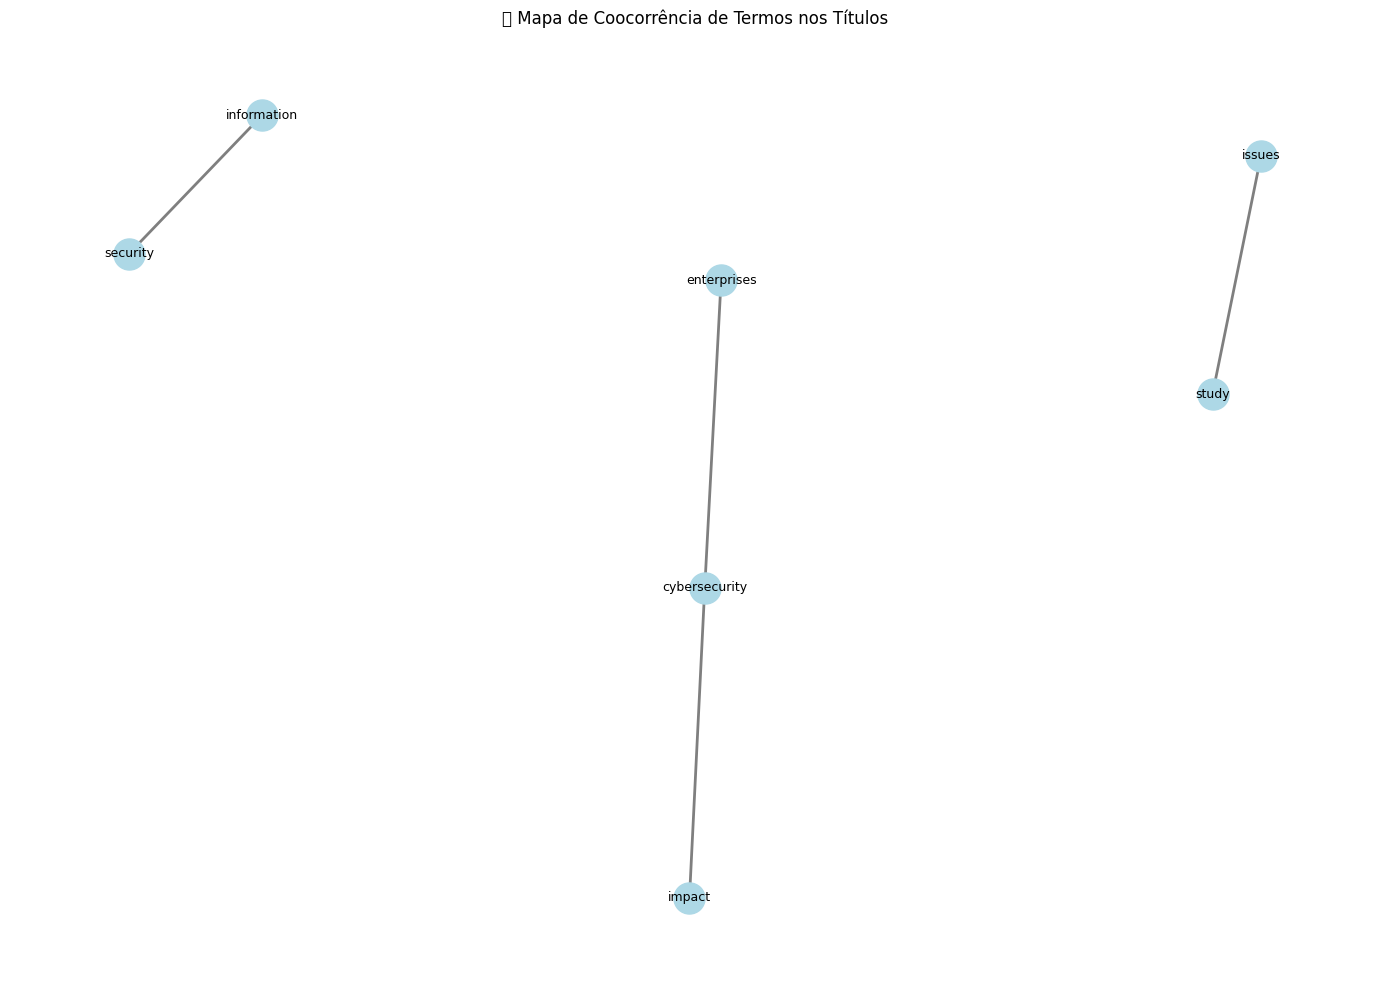

In [32]:
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter
import re
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

# Lista de stopwords em inglês
stop_words = set(stopwords.words('english'))

# Extrair títulos
titulos = [entry.get("title", "") for entry in bib_database.entries if "title" in entry]

# Pré-processa os títulos
todas_palavras = []
pares_coocorrencia = []

for titulo in titulos:
    # Remover pontuação e converte para minúsculas
    titulo_limpo = re.sub(r'[^\w\s]', '', titulo.lower())
    palavras = [w for w in titulo_limpo.split() if w not in stop_words and len(w) > 2]
    todas_palavras.extend(palavras)
    pares_coocorrencia.extend(combinations(set(palavras), 2))  # combinações únicas

# Contar pares de coocorrência
contagem_pares = Counter(pares_coocorrencia)
pares_mais_comuns = {par: freq for par, freq in contagem_pares.items() if freq >= 2}

# Criar grafo
G = nx.Graph()
for (w1, w2), peso in pares_mais_comuns.items():
    G.add_edge(w1, w2, weight=peso)

# Visualização
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=0.9)

nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=500)
nx.draw_networkx_edges(G, pos, width=[G[u][v]['weight'] for u,v in G.edges()], alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=9)

plt.title("🌐 Mapa de Coocorrência de Termos nos Títulos")
plt.axis("off")
plt.tight_layout()
plt.show()


###  Interpretação do Mapa de Coocorrência de Termos nos Títulos

O grafo apresentado representa a coocorrência entre termos relevantes extraídos dos títulos dos artigos da base analisada. Cada **nó** representa uma palavra significativa, enquanto cada **aresta** indica que os termos conectados apareceram juntos em pelo menos dois títulos diferentes.

Mesmo com um número reduzido de conexões fortes — o que é natural em bases pequenas e heterogêneas — algumas relações semânticas importantes foram identificadas:

- **"Cybersecurity" aparece conectado a "enterprises" e "impact"**, indicando que muitos estudos analisam os efeitos da segurança cibernética no contexto empresarial, refletindo preocupações práticas da área;

- **"Information" está ligado a "security"**, um agrupamento clássico que reforça a centralidade da temática de **segurança da informação** como subcampo dominante;

- **"Study" e "issues"** também aparecem relacionados, sugerindo que vários trabalhos têm caráter exploratório ou analítico, voltado à investigação de problemas específicos no setor;

A escassez de outras conexões pode estar ligada ao fato de que os títulos da base contêm termos diversos e muitas vezes não padronizados, o que dispersa a frequência de coocorrência.

###  Considerações

Apesar da densidade limitada da rede, o mapa cumpre seu papel ao evidenciar **as principais associações temáticas** e reforçar a coerência da base de referências com o objeto de estudo do MVP, especialmente no que se refere à relação entre **segurança cibernética**, **impactos organizacionais** e **análises de cargos e salários**.



###  Tendência Temporal de Termos

Esta análise visa identificar a **evolução de temas ao longo dos anos** com base nas palavras extraídas dos títulos dos artigos. Ao visualizar como certos termos aparecem com maior ou menor frequência em diferentes anos, é possível:

- Detectar **temas emergentes ou em declínio**;
- Compreender mudanças de foco na literatura;
- Apoiar decisões de delimitação do escopo do artigo científico.

Serão utilizados dados dos campos `title` e `year` de cada artigo para gerar uma linha do tempo por palavra mais frequente.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/tmp/ipython-input-3037444841.py:39: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


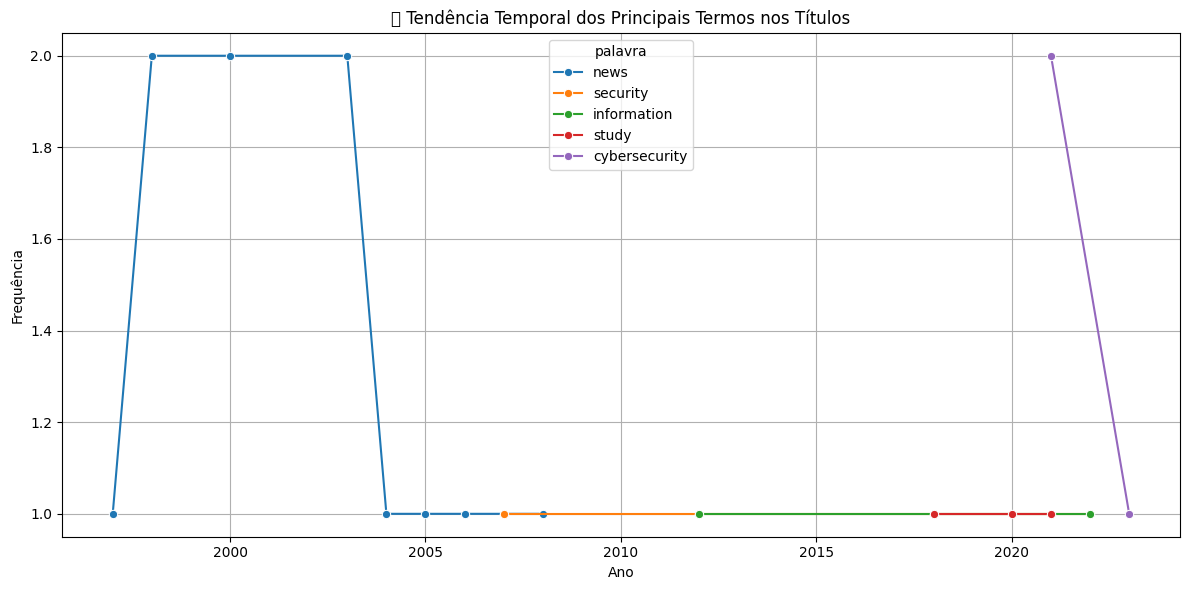

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk
import re

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Extrai título e ano
dados_titulo_ano = []
for entry in bib_database.entries:
    titulo = entry.get("title", "")
    ano = entry.get("year", "")
    if titulo and ano.isdigit():
        palavras = re.sub(r"[^\w\s]", "", titulo.lower()).split()
        palavras_filtradas = [w for w in palavras if w not in stop_words and len(w) > 3]
        for palavra in palavras_filtradas:
            dados_titulo_ano.append({"ano": int(ano), "palavra": palavra})

# Cria DataFrame
df_temporal = pd.DataFrame(dados_titulo_ano)

# Filtra termos mais frequentes
termos_frequentes = df_temporal["palavra"].value_counts().head(5).index
df_filtrado = df_temporal[df_temporal["palavra"].isin(termos_frequentes)]

# Agrupa por ano e termo
df_plot = df_filtrado.groupby(["ano", "palavra"]).size().reset_index(name="frequencia")

# Gráfico
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x="ano", y="frequencia", hue="palavra", marker="o")
plt.title("📊 Tendência Temporal dos Principais Termos nos Títulos")
plt.xlabel("Ano")
plt.ylabel("Frequência")
plt.grid(True)
plt.tight_layout()
plt.show()


###  Análise de Tendência Temporal dos Principais Termos

O gráfico de tendência temporal ilustra a frequência de ocorrência dos **cinco termos mais relevantes** nos títulos dos artigos ao longo dos anos, revelando padrões de interesse na literatura analisada.

####  Termos em destaque:

- **News**: É o termo mais recorrente nos anos anteriores a 2010, com picos entre 1998 e 2004. A forte presença se deve à inclusão de artigos oriundos de fontes jornalísticas e menos acadêmicas — indicando que parte da base bibliográfica tem caráter informativo ou de opinião sobre temas de tecnologia e trabalho.

- **Cybersecurity**: Surge somente nos anos mais recentes (após 2020), evidenciando o **caráter emergente e atual** desse tema. Isso reforça a escolha do recorte temático do projeto, pois demonstra que a segurança cibernética se consolidou como um tópico moderno e de interesse crescente.

- **Information**, **Security** e **Study**: São termos técnicos que aparecem de forma esporádica ao longo dos anos, refletindo estudos acadêmicos mais pontuais. A baixa frequência pode estar relacionada ao tamanho reduzido da base de dados ou à diversidade de temas.

---

###  Considerações

A análise temporal confirma que **o interesse por cibersegurança e salários** é mais recente, ao passo que os materiais mais antigos estavam voltados a aspectos gerais de trabalho e tecnologia. Essa constatação é coerente com a **evolução histórica das demandas de proteção de dados, digitalização e valorização de especialistas na área de TI**, e justifica a construção do MVP com base em dados atuais e focados.

Além disso, a baixa densidade da série histórica reforça a sugestão de que bases futuras devem conter **maior volume de dados mais recentes**, a fim de aprofundar o entendimento das **tendências emergentes** na literatura técnico-científica.
